In a Python Notebook, implement the functions that are able to provide the following graph embeddings:

    Only count the number of vertices for each possible label value (slide 23)
    Add the number of edges with two specific labels at end vertices (slide 24)
    Graph probing (add the count for edge structures) (slide 26)
    Choose one of the two embedding function:
        Count the number of occurrences of graph patterns. The graph pattern dictionnary is given as a parameter
        Count the number of occurences of all non-isomorphic pattern whose number of edges is lower than $n$. $n$ is given as a parameter (slide 35)
    Count the number of cycles of length 3, 4 and 5 (Slide 38)

Apply a classification algorithm (knn for example) based on these embeddings with the provided datasets :

    molhiv dataset from OGB.
    Alkane
    Benzene

In [6]:
import networkx as nx
import networkx as nx
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import accuracy_score
from networkx.algorithms import isomorphism
from ogb.graphproppred import GraphPropPredDataset
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from seaborn import heatmap
import matplotlib.pyplot as plt

### utils

In [7]:
def smiles_to_networkx(smiles):
    # Convert molecule
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid: {smiles}")
    graph = nx.Graph()
    AllChem.Compute2DCoords(mol)
    # Creating nodes
    for atom in mol.GetAtoms():
        idx = atom.GetIdx()
        pos = mol.GetConformer().GetAtomPosition(idx)
        graph.add_node(
            atom.GetIdx(),
            symbol=atom.GetSymbol(),
            position=(round(pos.x, 4), round(pos.y, 4))
        )
    # Creating edges
    for bond in mol.GetBonds():
        graph.add_edge(
            bond.GetBeginAtomIdx(),
            bond.GetEndAtomIdx(),
            bond_type=str(bond.GetBondType()),
        )
    return graph

def ogb_mol_to_networkx(ogb_graph):
    """
    Convertit un graph OGB MolHIV en graphe NetworkX
    avec les numéros atomiques et types de liaisons.
    """
    G = nx.Graph()

    node_feat = ogb_graph['node_feat']
    edge_index = ogb_graph['edge_index']
    edge_feat = ogb_graph['edge_feat']

    # --- Ajouter les noeuds ---
    for i, feat in enumerate(node_feat):
        atomic_number = int(feat[0])  # MolHIV: atomic_number est directement stocké
        G.add_node(i, atomic_num=atomic_number)

    # --- Ajouter les arêtes ---
    for e in range(edge_index.shape[1]):
        u = int(edge_index[0, e])
        v = int(edge_index[1, e])
        bond_type = int(edge_feat[e][0])  # 1=single, 2=double, 3=triple, 4=aromatic
        G.add_edge(u, v, bond_type=bond_type)

    return G


def chargement_donnees(df):
    X = []
    y = []
    for i, j in df.iterrows():
        smiles = j['smiles']
        target = j['label']
        network = smiles_to_networkx(smiles)
        X.append(network)
        y.append(target)
    return X, y

def transforme_to_matrix(X_graphs, y_labels, dataset_name="Dataset"):
    print(f"========== Traitement de {dataset_name} ==========")
    print(f"Nombre de graphes : {len(X_graphs)}")
    if hasattr(y_labels, 'shape') or isinstance(y_labels, np.ndarray):
        y_labels = np.array(y_labels).ravel()
    
    embeddings = []
    print("Extraction des features en cours...")
    for i, g in enumerate(X_graphs):
        features = {}
        features.update(count_nodes_for_label(g))
        features.update(count_number_edges(g))
        features.update(count_edges_structures(g))
        features.update(count_patterns(g, patterns_dict))
        features.update(count_cycles_specific(g))
        embeddings.append(features)
        
        if (i+1) % 1000 == 0:
            print(f"  > {i+1} graphes traités")
    
    
    vec = DictVectorizer(sparse=False)
    X_matrix = vec.fit_transform(embeddings)
    print(f"Matrice générée : {X_matrix.shape} (Graphes x Features)")
    return X_matrix, y_labels

#### Data

a. molhiv dataset from OGB.

In [9]:
dataset = GraphPropPredDataset(name="ogbg-molhiv")
df_molhiv = pd.read_csv('dataset/ogbg_molhiv/mapping/mol.csv.gz')
y_molhiv_raw = dataset.labels

print("Chargement et conversion Molhiv en cours...")
X_molhiv = []
y_molhiv = []

# for index, row in df_molhiv.iterrows(): #je l'ai fais avec les 43k graphes mais pour eviter de predre du temps decommenter la ligne d'en bas
for index, row in df_molhiv.iloc[:2000].iterrows():
    try:
        g = smiles_to_networkx(row['smiles'])
        X_molhiv.append(g)
        y_molhiv.append(y_molhiv_raw[index][0])
    except:
        pass
print(f"Molhiv chargé : {len(X_molhiv)} graphes")

Downloaded 0.00 GB: 100%|██████████| 3/3 [00:02<00:00,  1.21it/s]


Extracting dataset\hiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 41127/41127 [00:00<00:00, 191442.79it/s]


Saving...
Chargement et conversion Molhiv en cours...


[23:44:11] Explicit valence for atom # 3 Al, 6, is greater than permitted
[23:44:12] Explicit valence for atom # 5 B, 5, is greater than permitted


Molhiv chargé : 1998 graphes


b. Alkane

In [10]:
print("Chargement Alkane...")
df_alkane = pd.read_csv('AC_smiles.csv')
df_alkane
X_alkane , y_alkane = chargement_donnees(df_alkane)
len(X_alkane), len(y_alkane)

Chargement Alkane...


(4326, 4326)

c. Benzene 

In [11]:
df_benzene = pd.read_csv('benzene_smiles.csv')
X_benzene, y_benzene = chargement_donnees(df_benzene)
len(X_benzene), len(y_benzene)

(12000, 12000)

#### 1. Only count the number of vertices for each possible label value (slide 23)

In [12]:
def count_nodes_for_label(graph):
    count = {}
    for node, data in graph.nodes(data=True):
        lbl = data.get("symbol")
        count[f"Node_{lbl}"] = count.get(f"Node_{lbl}", 0) + 1
    return count

molhiv

In [13]:
for i in range(5):
    g = X_molhiv[i]
    print(f"{g.nodes(data=True)}: \n{count_nodes_for_label(g)}\n\n")

[(0, {'symbol': 'C', 'position': (1.7114, -4.1619)}), (1, {'symbol': 'C', 'position': (2.6276, -2.9742)}), (2, {'symbol': 'C', 'position': (2.0571, -1.5869)}), (3, {'symbol': 'O', 'position': (0.5705, -1.3873)}), (4, {'symbol': 'Cu', 'position': (0.0, 0.0)}), (5, {'symbol': 'O', 'position': (0.9162, 1.1877)}), (6, {'symbol': 'C', 'position': (2.4029, 0.9881)}), (7, {'symbol': 'C', 'position': (3.3191, 2.1757)}), (8, {'symbol': 'C', 'position': (4.8057, 1.9761)}), (9, {'symbol': 'C', 'position': (2.9733, -0.3992)}), (10, {'symbol': 'O', 'position': (-0.5705, 1.3873)}), (11, {'symbol': 'C', 'position': (-2.0571, 1.5869)}), (12, {'symbol': 'C', 'position': (-2.6276, 2.9742)}), (13, {'symbol': 'C', 'position': (-1.7114, 4.1619)}), (14, {'symbol': 'C', 'position': (-2.9733, 0.3992)}), (15, {'symbol': 'C', 'position': (-2.4029, -0.9881)}), (16, {'symbol': 'C', 'position': (-3.3191, -2.1757)}), (17, {'symbol': 'C', 'position': (-4.8057, -1.9761)}), (18, {'symbol': 'O', 'position': (-0.9162, -

alkane

In [ ]:
for i in range(5):
    g = X_alkane[i]
    print(f"{g.nodes(data=True)}: \n{count_nodes_for_label(g)}\n\n")

[(0, {'symbol': 'C', 'position': (2.508, -5.588)}), (1, {'symbol': 'C', 'position': (2.3058, -4.1017)}), (2, {'symbol': 'O', 'position': (0.9176, -3.5336)}), (3, {'symbol': 'C', 'position': (0.7154, -2.0473)}), (4, {'symbol': 'C', 'position': (-0.6728, -1.4792)}), (5, {'symbol': 'C', 'position': (-0.875, 0.0072)}), (6, {'symbol': 'C', 'position': (0.3111, 0.9254)}), (7, {'symbol': 'C', 'position': (1.6994, 0.3573)}), (8, {'symbol': 'N', 'position': (1.9015, -1.129)}), (9, {'symbol': 'C', 'position': (2.8855, 1.2755)}), (10, {'symbol': 'C', 'position': (4.2738, 0.7074)}), (11, {'symbol': 'C', 'position': (5.4599, 1.6256)}), (12, {'symbol': 'C', 'position': (5.2578, 3.1119)}), (13, {'symbol': 'C', 'position': (3.8695, 3.68)}), (14, {'symbol': 'C', 'position': (2.6834, 2.7618)}), (15, {'symbol': 'C', 'position': (-2.2632, 0.5753)}), (16, {'symbol': 'C', 'position': (-2.4654, 2.0616)}), (17, {'symbol': 'C', 'position': (-3.8536, 2.6297)}), (18, {'symbol': 'C', 'position': (-5.0397, 1.7115)

benzene

In [ ]:
for i in range(5):
    g = X_benzene[i]
    print(f"{g.nodes(data=True)}: \n{count_nodes_for_label(g)}\n\n")

[(0, {'symbol': 'C', 'position': (0.6975, -0.4851)}), (1, {'symbol': 'C', 'position': (-0.8019, -0.5244)}), (2, {'symbol': 'C', 'position': (-1.5857, 0.7546)}), (3, {'symbol': 'N', 'position': (-0.8699, 2.0728)}), (4, {'symbol': 'C', 'position': (0.6296, 2.1121)}), (5, {'symbol': 'C', 'position': (1.4133, 0.8331)}), (6, {'symbol': 'N', 'position': (2.9128, 0.8723)}), (7, {'symbol': 'C', 'position': (3.6965, -0.4066)}), (8, {'symbol': 'O', 'position': (2.9808, -1.7249)}), (9, {'symbol': 'C', 'position': (5.196, -0.3674)}), (10, {'symbol': 'C', 'position': (5.9797, -1.6464)}), (11, {'symbol': 'C', 'position': (7.4792, -1.6071)}), (12, {'symbol': 'C', 'position': (8.195, -0.2889)}), (13, {'symbol': 'C', 'position': (7.4112, 0.9901)}), (14, {'symbol': 'C', 'position': (5.9118, 0.9508)}), (15, {'symbol': 'N', 'position': (-3.0852, 0.7153)}), (16, {'symbol': 'C', 'position': (-3.9348, -0.5208)}), (17, {'symbol': 'C', 'position': (-5.373, -0.0948)}), (18, {'symbol': 'C', 'position': (-5.4123,

#### 2. Add the number of edges with two specific labels at end vertices (slide 24)

In [ ]:
def count_number_edges(graph):
    count = {}
    for u, v, data in graph.edges(data=True):
        l1 = graph.nodes[u].get('symbol')
        l2 = graph.nodes[v].get('symbol')
        edge_lbl = data.get('bond_type', 'Single') 
        lbl_pair = tuple(sorted((l1, l2)))
        key = f"Edge_{lbl_pair[0]}_{edge_lbl}_{lbl_pair[1]}"
        
        count[key] = count.get(key, 0) + 1
    return count

molhiv

In [ ]:
for i in range(5):
    g = X_molhiv[i]
    print(f"{g.nodes(data=True)}: \n{count_number_edges(g)}\n\n")

[(0, {'symbol': 'C', 'position': (1.7114, -4.1619)}), (1, {'symbol': 'C', 'position': (2.6276, -2.9742)}), (2, {'symbol': 'C', 'position': (2.0571, -1.5869)}), (3, {'symbol': 'O', 'position': (0.5705, -1.3873)}), (4, {'symbol': 'Cu', 'position': (0.0, 0.0)}), (5, {'symbol': 'O', 'position': (0.9162, 1.1877)}), (6, {'symbol': 'C', 'position': (2.4029, 0.9881)}), (7, {'symbol': 'C', 'position': (3.3191, 2.1757)}), (8, {'symbol': 'C', 'position': (4.8057, 1.9761)}), (9, {'symbol': 'C', 'position': (2.9733, -0.3992)}), (10, {'symbol': 'O', 'position': (-0.5705, 1.3873)}), (11, {'symbol': 'C', 'position': (-2.0571, 1.5869)}), (12, {'symbol': 'C', 'position': (-2.6276, 2.9742)}), (13, {'symbol': 'C', 'position': (-1.7114, 4.1619)}), (14, {'symbol': 'C', 'position': (-2.9733, 0.3992)}), (15, {'symbol': 'C', 'position': (-2.4029, -0.9881)}), (16, {'symbol': 'C', 'position': (-3.3191, -2.1757)}), (17, {'symbol': 'C', 'position': (-4.8057, -1.9761)}), (18, {'symbol': 'O', 'position': (-0.9162, -

alkane

In [ ]:
for i in range(5):
    g = X_alkane[i]
    print(f"{g.edges(data=True)}: \n{count_number_edges(g)}\n\n")

[(0, 1, {'bond_type': 'SINGLE'}), (1, 2, {'bond_type': 'SINGLE'}), (2, 3, {'bond_type': 'SINGLE'}), (3, 4, {'bond_type': 'AROMATIC'}), (3, 8, {'bond_type': 'AROMATIC'}), (4, 5, {'bond_type': 'AROMATIC'}), (4, 22, {'bond_type': 'SINGLE'}), (5, 6, {'bond_type': 'AROMATIC'}), (5, 15, {'bond_type': 'SINGLE'}), (6, 7, {'bond_type': 'AROMATIC'}), (7, 8, {'bond_type': 'AROMATIC'}), (7, 9, {'bond_type': 'SINGLE'}), (9, 10, {'bond_type': 'AROMATIC'}), (9, 14, {'bond_type': 'AROMATIC'}), (10, 11, {'bond_type': 'AROMATIC'}), (11, 12, {'bond_type': 'AROMATIC'}), (12, 13, {'bond_type': 'AROMATIC'}), (13, 14, {'bond_type': 'AROMATIC'}), (15, 16, {'bond_type': 'AROMATIC'}), (15, 20, {'bond_type': 'AROMATIC'}), (16, 17, {'bond_type': 'AROMATIC'}), (17, 18, {'bond_type': 'AROMATIC'}), (18, 19, {'bond_type': 'AROMATIC'}), (18, 21, {'bond_type': 'SINGLE'}), (19, 20, {'bond_type': 'AROMATIC'}), (22, 23, {'bond_type': 'TRIPLE'})]: 
{'Edge_C_SINGLE_C': 5, 'Edge_C_SINGLE_O': 2, 'Edge_C_AROMATIC_C': 16, 'Edge

benzene

In [ ]:
for i in range(5):
    g = X_benzene[i]
    print(f"{g.edges(data=True)}: \n{count_number_edges(g)}\n\n")

[(0, 1, {'bond_type': 'AROMATIC'}), (0, 5, {'bond_type': 'AROMATIC'}), (1, 2, {'bond_type': 'AROMATIC'}), (2, 3, {'bond_type': 'AROMATIC'}), (2, 15, {'bond_type': 'SINGLE'}), (3, 4, {'bond_type': 'AROMATIC'}), (4, 5, {'bond_type': 'AROMATIC'}), (5, 6, {'bond_type': 'SINGLE'}), (6, 7, {'bond_type': 'SINGLE'}), (7, 8, {'bond_type': 'DOUBLE'}), (7, 9, {'bond_type': 'SINGLE'}), (9, 10, {'bond_type': 'SINGLE'}), (9, 14, {'bond_type': 'SINGLE'}), (10, 11, {'bond_type': 'SINGLE'}), (11, 12, {'bond_type': 'SINGLE'}), (12, 13, {'bond_type': 'SINGLE'}), (13, 14, {'bond_type': 'SINGLE'}), (15, 16, {'bond_type': 'AROMATIC'}), (15, 19, {'bond_type': 'AROMATIC'}), (16, 17, {'bond_type': 'AROMATIC'}), (17, 18, {'bond_type': 'AROMATIC'}), (17, 20, {'bond_type': 'SINGLE'}), (18, 19, {'bond_type': 'AROMATIC'}), (20, 21, {'bond_type': 'DOUBLE'}), (20, 22, {'bond_type': 'DOUBLE'}), (20, 23, {'bond_type': 'SINGLE'})]: 
{'Edge_C_AROMATIC_C': 6, 'Edge_C_AROMATIC_N': 4, 'Edge_C_SINGLE_N': 3, 'Edge_C_DOUBLE_O'

In [ ]:
def count_label_of_edges(graph):
    count, edges = {}, list(graph.edges(data=True))
    labels = [edges[_][2]['bond_type'] for _ in range(len(edges))]
    for _ in labels:
        count[_] = 0
    for i,j,data in graph.edges(data=True):
        if data.get("bond_type") in labels:
            count[data.get("bond_type")] += 1
    return count

molhiv

In [ ]:
for i in range(5):
    g = X_molhiv[i]
    print(f"{g.nodes(data=True)}: \n{count_label_of_edges(g)}\n\n")

[(0, {'symbol': 'C', 'position': (1.7114, -4.1619)}), (1, {'symbol': 'C', 'position': (2.6276, -2.9742)}), (2, {'symbol': 'C', 'position': (2.0571, -1.5869)}), (3, {'symbol': 'O', 'position': (0.5705, -1.3873)}), (4, {'symbol': 'Cu', 'position': (0.0, 0.0)}), (5, {'symbol': 'O', 'position': (0.9162, 1.1877)}), (6, {'symbol': 'C', 'position': (2.4029, 0.9881)}), (7, {'symbol': 'C', 'position': (3.3191, 2.1757)}), (8, {'symbol': 'C', 'position': (4.8057, 1.9761)}), (9, {'symbol': 'C', 'position': (2.9733, -0.3992)}), (10, {'symbol': 'O', 'position': (-0.5705, 1.3873)}), (11, {'symbol': 'C', 'position': (-2.0571, 1.5869)}), (12, {'symbol': 'C', 'position': (-2.6276, 2.9742)}), (13, {'symbol': 'C', 'position': (-1.7114, 4.1619)}), (14, {'symbol': 'C', 'position': (-2.9733, 0.3992)}), (15, {'symbol': 'C', 'position': (-2.4029, -0.9881)}), (16, {'symbol': 'C', 'position': (-3.3191, -2.1757)}), (17, {'symbol': 'C', 'position': (-4.8057, -1.9761)}), (18, {'symbol': 'O', 'position': (-0.9162, -

alkane

In [ ]:
for i in range(5):
    g = X_alkane[i]
    print(f"{g.edges(data=True)}: \n{count_label_of_edges(g)}\n\n")

[(0, 1, {'bond_type': 'SINGLE'}), (1, 2, {'bond_type': 'SINGLE'}), (2, 3, {'bond_type': 'SINGLE'}), (3, 4, {'bond_type': 'AROMATIC'}), (3, 8, {'bond_type': 'AROMATIC'}), (4, 5, {'bond_type': 'AROMATIC'}), (4, 22, {'bond_type': 'SINGLE'}), (5, 6, {'bond_type': 'AROMATIC'}), (5, 15, {'bond_type': 'SINGLE'}), (6, 7, {'bond_type': 'AROMATIC'}), (7, 8, {'bond_type': 'AROMATIC'}), (7, 9, {'bond_type': 'SINGLE'}), (9, 10, {'bond_type': 'AROMATIC'}), (9, 14, {'bond_type': 'AROMATIC'}), (10, 11, {'bond_type': 'AROMATIC'}), (11, 12, {'bond_type': 'AROMATIC'}), (12, 13, {'bond_type': 'AROMATIC'}), (13, 14, {'bond_type': 'AROMATIC'}), (15, 16, {'bond_type': 'AROMATIC'}), (15, 20, {'bond_type': 'AROMATIC'}), (16, 17, {'bond_type': 'AROMATIC'}), (17, 18, {'bond_type': 'AROMATIC'}), (18, 19, {'bond_type': 'AROMATIC'}), (18, 21, {'bond_type': 'SINGLE'}), (19, 20, {'bond_type': 'AROMATIC'}), (22, 23, {'bond_type': 'TRIPLE'})]: 
{'SINGLE': 7, 'AROMATIC': 18, 'TRIPLE': 1}


[(0, 1, {'bond_type': 'AROMATI

benzene

In [ ]:
for i in range(5):
    g = X_alkane[i]
    print(f"{g.edges(data=True)}: \n{count_label_of_edges(g)}\n\n")

[(0, 1, {'bond_type': 'SINGLE'}), (1, 2, {'bond_type': 'SINGLE'}), (2, 3, {'bond_type': 'SINGLE'}), (3, 4, {'bond_type': 'AROMATIC'}), (3, 8, {'bond_type': 'AROMATIC'}), (4, 5, {'bond_type': 'AROMATIC'}), (4, 22, {'bond_type': 'SINGLE'}), (5, 6, {'bond_type': 'AROMATIC'}), (5, 15, {'bond_type': 'SINGLE'}), (6, 7, {'bond_type': 'AROMATIC'}), (7, 8, {'bond_type': 'AROMATIC'}), (7, 9, {'bond_type': 'SINGLE'}), (9, 10, {'bond_type': 'AROMATIC'}), (9, 14, {'bond_type': 'AROMATIC'}), (10, 11, {'bond_type': 'AROMATIC'}), (11, 12, {'bond_type': 'AROMATIC'}), (12, 13, {'bond_type': 'AROMATIC'}), (13, 14, {'bond_type': 'AROMATIC'}), (15, 16, {'bond_type': 'AROMATIC'}), (15, 20, {'bond_type': 'AROMATIC'}), (16, 17, {'bond_type': 'AROMATIC'}), (17, 18, {'bond_type': 'AROMATIC'}), (18, 19, {'bond_type': 'AROMATIC'}), (18, 21, {'bond_type': 'SINGLE'}), (19, 20, {'bond_type': 'AROMATIC'}), (22, 23, {'bond_type': 'TRIPLE'})]: 
{'SINGLE': 7, 'AROMATIC': 18, 'TRIPLE': 1}


[(0, 1, {'bond_type': 'AROMATI

#### 3. Graph probing (add the count for edge structures) (slide 26)

In [ ]:
def count_edges_structures(graph):
    count = {}
    for u, v in graph.edges():
        l1 = graph.nodes[u].get('symbol', graph.nodes[u].get('label', 'Unknown'))
        l2 = graph.nodes[v].get('symbol', graph.nodes[v].get('label', 'Unknown'))
        pair = tuple(sorted((l1, l2)))
        key = f"Struct_{pair[0]}_{pair[1]}"
        count[key] = count.get(key, 0) + 1
    return count

molhiv

In [ ]:
for i in range(5):
    g = X_molhiv[i]
    print(f"{g.edges(data=True)}: \n{count_edges_structures(g)}\n\n")

[(0, 1, {'bond_type': 'SINGLE'}), (1, 2, {'bond_type': 'SINGLE'}), (2, 3, {'bond_type': 'DOUBLE'}), (2, 9, {'bond_type': 'SINGLE'}), (3, 4, {'bond_type': 'SINGLE'}), (4, 5, {'bond_type': 'SINGLE'}), (4, 10, {'bond_type': 'SINGLE'}), (4, 18, {'bond_type': 'SINGLE'}), (5, 6, {'bond_type': 'DOUBLE'}), (6, 7, {'bond_type': 'SINGLE'}), (6, 9, {'bond_type': 'SINGLE'}), (7, 8, {'bond_type': 'SINGLE'}), (10, 11, {'bond_type': 'DOUBLE'}), (11, 12, {'bond_type': 'SINGLE'}), (11, 14, {'bond_type': 'SINGLE'}), (12, 13, {'bond_type': 'SINGLE'}), (14, 15, {'bond_type': 'SINGLE'}), (15, 16, {'bond_type': 'SINGLE'}), (15, 18, {'bond_type': 'DOUBLE'}), (16, 17, {'bond_type': 'SINGLE'})]: 
{'Struct_C_C': 12, 'Struct_C_O': 4, 'Struct_Cu_O': 4}


[(0, 1, {'bond_type': 'DOUBLE'}), (0, 8, {'bond_type': 'SINGLE'}), (1, 2, {'bond_type': 'SINGLE'}), (2, 3, {'bond_type': 'AROMATIC'}), (2, 7, {'bond_type': 'AROMATIC'}), (3, 4, {'bond_type': 'AROMATIC'}), (4, 5, {'bond_type': 'AROMATIC'}), (5, 6, {'bond_type': 'A

alkane

In [ ]:
for i in range(5):
    g = X_alkane[i]
    print(f"{g.edges(data=True)}: \n{count_edges_structures(g)}\n\n")

[(0, 1, {'bond_type': 'SINGLE'}), (1, 2, {'bond_type': 'SINGLE'}), (2, 3, {'bond_type': 'SINGLE'}), (3, 4, {'bond_type': 'AROMATIC'}), (3, 8, {'bond_type': 'AROMATIC'}), (4, 5, {'bond_type': 'AROMATIC'}), (4, 22, {'bond_type': 'SINGLE'}), (5, 6, {'bond_type': 'AROMATIC'}), (5, 15, {'bond_type': 'SINGLE'}), (6, 7, {'bond_type': 'AROMATIC'}), (7, 8, {'bond_type': 'AROMATIC'}), (7, 9, {'bond_type': 'SINGLE'}), (9, 10, {'bond_type': 'AROMATIC'}), (9, 14, {'bond_type': 'AROMATIC'}), (10, 11, {'bond_type': 'AROMATIC'}), (11, 12, {'bond_type': 'AROMATIC'}), (12, 13, {'bond_type': 'AROMATIC'}), (13, 14, {'bond_type': 'AROMATIC'}), (15, 16, {'bond_type': 'AROMATIC'}), (15, 20, {'bond_type': 'AROMATIC'}), (16, 17, {'bond_type': 'AROMATIC'}), (17, 18, {'bond_type': 'AROMATIC'}), (18, 19, {'bond_type': 'AROMATIC'}), (18, 21, {'bond_type': 'SINGLE'}), (19, 20, {'bond_type': 'AROMATIC'}), (22, 23, {'bond_type': 'TRIPLE'})]: 
{'Struct_C_C': 21, 'Struct_C_O': 2, 'Struct_C_N': 3}


[(0, 1, {'bond_type'

benzene

In [ ]:
for i in range(5):
    g = X_benzene[i]
    print(f"{g.edges(data=True)}: \n{count_edges_structures(g)}\n\n")

[(0, 1, {'bond_type': 'AROMATIC'}), (0, 5, {'bond_type': 'AROMATIC'}), (1, 2, {'bond_type': 'AROMATIC'}), (2, 3, {'bond_type': 'AROMATIC'}), (2, 15, {'bond_type': 'SINGLE'}), (3, 4, {'bond_type': 'AROMATIC'}), (4, 5, {'bond_type': 'AROMATIC'}), (5, 6, {'bond_type': 'SINGLE'}), (6, 7, {'bond_type': 'SINGLE'}), (7, 8, {'bond_type': 'DOUBLE'}), (7, 9, {'bond_type': 'SINGLE'}), (9, 10, {'bond_type': 'SINGLE'}), (9, 14, {'bond_type': 'SINGLE'}), (10, 11, {'bond_type': 'SINGLE'}), (11, 12, {'bond_type': 'SINGLE'}), (12, 13, {'bond_type': 'SINGLE'}), (13, 14, {'bond_type': 'SINGLE'}), (15, 16, {'bond_type': 'AROMATIC'}), (15, 19, {'bond_type': 'AROMATIC'}), (16, 17, {'bond_type': 'AROMATIC'}), (17, 18, {'bond_type': 'AROMATIC'}), (17, 20, {'bond_type': 'SINGLE'}), (18, 19, {'bond_type': 'AROMATIC'}), (20, 21, {'bond_type': 'DOUBLE'}), (20, 22, {'bond_type': 'DOUBLE'}), (20, 23, {'bond_type': 'SINGLE'})]: 
{'Struct_C_C': 13, 'Struct_C_N': 7, 'Struct_C_O': 1, 'Struct_N_N': 1, 'Struct_C_S': 1, '

#### 4. Count the number of occurrences of graph patterns. The graph pattern dictionnary is given as a parameter

In [ ]:
def count_patterns(graph, patterns):
    counts = {}
    for name, pattern in patterns.items():
        GM = isomorphism.GraphMatcher(graph, pattern)
        try:
            n = sum(1 for _ in GM.subgraph_isomorphisms_iter())
            counts[f"Pat_{name}"] = n
        except:
            counts[f"Pat_{name}"] = 0
    return counts

In [ ]:
patterns_dict = {
    'cycle_3': nx.cycle_graph(3),
    'cycle_4': nx.cycle_graph(4),
    'cycle_5': nx.cycle_graph(5),
    'cycle_6': nx.cycle_graph(6),  
    'path_3': nx.path_graph(3),    
    'star_3': nx.star_graph(3)  
}

molhiv

In [ ]:
for i in range(5):
    g = X_molhiv[i]
    print(f"{count_patterns(g, patterns_dict)}")

{'Pat_cycle_3': 0, 'Pat_cycle_4': 0, 'Pat_cycle_5': 0, 'Pat_cycle_6': 24, 'Pat_path_3': 56, 'Pat_star_3': 48}
{'Pat_cycle_3': 0, 'Pat_cycle_4': 0, 'Pat_cycle_5': 0, 'Pat_cycle_6': 72, 'Pat_path_3': 120, 'Pat_star_3': 72}
{'Pat_cycle_3': 0, 'Pat_cycle_4': 0, 'Pat_cycle_5': 0, 'Pat_cycle_6': 48, 'Pat_path_3': 70, 'Pat_star_3': 48}
{'Pat_cycle_3': 0, 'Pat_cycle_4': 0, 'Pat_cycle_5': 0, 'Pat_cycle_6': 24, 'Pat_path_3': 76, 'Pat_star_3': 84}
{'Pat_cycle_3': 0, 'Pat_cycle_4': 0, 'Pat_cycle_5': 0, 'Pat_cycle_6': 0, 'Pat_path_3': 28, 'Pat_star_3': 48}


alkane

In [ ]:
for i in range(5):
    g = X_alkane[i]
    print(f"{count_patterns(g, patterns_dict)}")

{'Pat_cycle_3': 0, 'Pat_cycle_4': 0, 'Pat_cycle_5': 0, 'Pat_cycle_6': 36, 'Pat_path_3': 70, 'Pat_star_3': 42}
{'Pat_cycle_3': 0, 'Pat_cycle_4': 0, 'Pat_cycle_5': 20, 'Pat_cycle_6': 12, 'Pat_path_3': 64, 'Pat_star_3': 30}
{'Pat_cycle_3': 0, 'Pat_cycle_4': 0, 'Pat_cycle_5': 10, 'Pat_cycle_6': 12, 'Pat_path_3': 54, 'Pat_star_3': 72}
{'Pat_cycle_3': 0, 'Pat_cycle_4': 0, 'Pat_cycle_5': 0, 'Pat_cycle_6': 12, 'Pat_path_3': 40, 'Pat_star_3': 42}
{'Pat_cycle_3': 6, 'Pat_cycle_4': 0, 'Pat_cycle_5': 30, 'Pat_cycle_6': 24, 'Pat_path_3': 80, 'Pat_star_3': 66}


benzene

In [ ]:
for i in range(5):
    g = X_benzene[i]
    print(f"{count_patterns(g, patterns_dict)}")

{'Pat_cycle_3': 0, 'Pat_cycle_4': 0, 'Pat_cycle_5': 10, 'Pat_cycle_6': 24, 'Pat_path_3': 74, 'Pat_star_3': 60}
{'Pat_cycle_3': 0, 'Pat_cycle_4': 0, 'Pat_cycle_5': 0, 'Pat_cycle_6': 24, 'Pat_path_3': 62, 'Pat_star_3': 36}
{'Pat_cycle_3': 0, 'Pat_cycle_4': 0, 'Pat_cycle_5': 10, 'Pat_cycle_6': 12, 'Pat_path_3': 38, 'Pat_star_3': 18}
{'Pat_cycle_3': 0, 'Pat_cycle_4': 0, 'Pat_cycle_5': 0, 'Pat_cycle_6': 24, 'Pat_path_3': 54, 'Pat_star_3': 42}
{'Pat_cycle_3': 0, 'Pat_cycle_4': 0, 'Pat_cycle_5': 0, 'Pat_cycle_6': 24, 'Pat_path_3': 60, 'Pat_star_3': 30}


#### 5. Count the number of cycles of length 3, 4 and 5 (Slide 38)

In [ ]:
def count_cycles_specific(graph):
    cycles_to_find = {
        '3': nx.cycle_graph(3),
        '4': nx.cycle_graph(4),
        '5': nx.cycle_graph(5)
    }
    
    counts = {}
    for size, pattern in cycles_to_find.items():
        GM = isomorphism.GraphMatcher(graph, pattern)
        try:
            raw_count = sum(1 for _ in GM.subgraph_isomorphisms_iter())
            if size == '3': divisor = 6
            elif size == '4': divisor = 8
            elif size == '5': divisor = 10
            else: divisor = 1    
            counts[f"Cycle_len_{size}"] = raw_count // divisor
        except:
            counts[f"Cycle_len_{size}"] = 0
    return counts

molhiv

In [ ]:
for i in range(5):
    g = X_molhiv[i]
    print(f"{count_cycles_specific(g)}")

{'Cycle_len_3': 0, 'Cycle_len_4': 0, 'Cycle_len_5': 0}
{'Cycle_len_3': 0, 'Cycle_len_4': 0, 'Cycle_len_5': 0}
{'Cycle_len_3': 0, 'Cycle_len_4': 0, 'Cycle_len_5': 0}
{'Cycle_len_3': 0, 'Cycle_len_4': 0, 'Cycle_len_5': 0}
{'Cycle_len_3': 0, 'Cycle_len_4': 0, 'Cycle_len_5': 0}


alkane

In [ ]:
for i in range(5):
    g = X_alkane[i]
    print(f"{count_cycles_specific(g)}")

{'Cycle_len_3': 0, 'Cycle_len_4': 0, 'Cycle_len_5': 0}
{'Cycle_len_3': 0, 'Cycle_len_4': 0, 'Cycle_len_5': 2}
{'Cycle_len_3': 0, 'Cycle_len_4': 0, 'Cycle_len_5': 1}
{'Cycle_len_3': 0, 'Cycle_len_4': 0, 'Cycle_len_5': 0}
{'Cycle_len_3': 1, 'Cycle_len_4': 0, 'Cycle_len_5': 3}


benzene

In [ ]:
for i in range(5):
    g = X_benzene[i]
    print(f"{count_cycles_specific(g)}")

{'Cycle_len_3': 0, 'Cycle_len_4': 0, 'Cycle_len_5': 1}
{'Cycle_len_3': 0, 'Cycle_len_4': 0, 'Cycle_len_5': 0}
{'Cycle_len_3': 0, 'Cycle_len_4': 0, 'Cycle_len_5': 1}
{'Cycle_len_3': 0, 'Cycle_len_4': 0, 'Cycle_len_5': 0}
{'Cycle_len_3': 0, 'Cycle_len_4': 0, 'Cycle_len_5': 0}


#### 6. Apply a classification algorithm (knn for example) based on these embeddings with the provided datasets : 

In [ ]:
def train(X_train, y_train, dataset_name="Dataset"):
    print(f"========== Entraînement sur {dataset_name} ==========")

    print("Entraînement du KNN...")
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    return knn

In [ ]:
def evaluate(model, X_test, y_test, dataset_name="Dataset"):
    print(f"========== Évaluation sur {dataset_name} ==========")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    TP, TN, FP, FN = confusion_matrix(y_test, y_pred).ravel()
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
    Precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    F1_score = 2 * (Precision * TPR) / (Precision + TPR) if (Precision + TPR) > 0 else 0
    AUC = roc_auc_score(y_test, y_pred)
    print("Métriques de performance :")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Rappel: {TPR:.4f}")
    print(f"Taux de faux positifs: {FPR:.4f}")
    print(f"Precision: {Precision:.4f}")
    print(f"F1 Score: {F1_score:.4f}")
    print(f"AUC: {AUC:.4f}")
    print(f"Matrice de confusion:")
    heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.show()
    

molhiv

In [ ]:
X_molhiv_matrice, y_molhiv_labels = transforme_to_matrix(X_molhiv, y_molhiv, "molhiv")
X_molhiv_train, X_molhiv_test, y_molhiv_train, y_molhiv_test = train_test_split(
    X_molhiv_matrice, y_molhiv_labels, test_size=0.2, random_state=42)

========== Traitement de molhiv ==========
Nombre de graphes : 41120
Extraction des features en cours...
  > 1000 graphes traités
  > 2000 graphes traités
  > 3000 graphes traités
  > 4000 graphes traités
  > 5000 graphes traités
  > 6000 graphes traités
  > 7000 graphes traités
  > 8000 graphes traités
  > 9000 graphes traités
  > 10000 graphes traités
  > 11000 graphes traités
  > 12000 graphes traités
  > 13000 graphes traités
  > 14000 graphes traités
  > 15000 graphes traités
  > 16000 graphes traités
  > 17000 graphes traités
  > 18000 graphes traités
  > 19000 graphes traités
  > 20000 graphes traités
  > 21000 graphes traités
  > 22000 graphes traités
  > 23000 graphes traités
  > 24000 graphes traités
  > 25000 graphes traités
  > 26000 graphes traités
  > 27000 graphes traités
  > 28000 graphes traités
  > 29000 graphes traités
  > 30000 graphes traités
  > 31000 graphes traités
  > 32000 graphes traités
  > 33000 graphes traités
  > 34000 graphes traités
  > 35000 graphes tr

In [ ]:
df_molhiv_y = pd.DataFrame(y_molhiv_labels, columns=['label'])
print(f"classe 1: {df_molhiv_y[df_molhiv_y['label'] == 1].value_counts().sum()}, classe 0: {df_molhiv_y[df_molhiv_y['label'] == 0].value_counts().sum()}")

classe 1: 1443, classe 0: 39677


Les classes n'étant pas bien équilibré il vaudrait mieux se fier au score de Taux positifs

========== Entraînement sur molhiv ==========
Entraînement du KNN...
========== Évaluation sur molhiv ==========
Métriques de performance :
Accuracy: 0.9726
Rappel: 0.9877
Taux de faux positifs: 0.8447
Precision: 0.9765
F1 Score: 0.9821
AUC: 0.6679
Matrice de confusion:


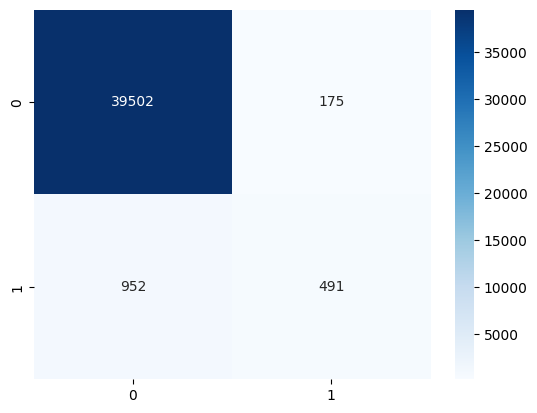

In [ ]:
model = train(X_molhiv_matrice, y_molhiv_labels, "molhiv")
evaluate(model, X_molhiv_matrice, y_molhiv_labels, "molhiv")

alkane

In [ ]:
X_alkane_matrice, y_alkane_labels = transforme_to_matrix(X_alkane, y_alkane, "Alkane")
X_alkane_train, X_alkane_test, y_alkane_train, y_alkane_test = train_test_split(
    X_alkane_matrice, y_alkane_labels, test_size=0.2, random_state=42)

========== Traitement de Alkane ==========
Nombre de graphes : 4326
Extraction des features en cours...
  > 1000 graphes traités
  > 2000 graphes traités
  > 3000 graphes traités
  > 4000 graphes traités
Matrice générée : (4326, 70) (Graphes x Features)


In [ ]:

print(f"classe 0: {df_alkane[df_alkane['label']==0].value_counts().sum()}, classe 1: {df_alkane[df_alkane['label']==1].value_counts().sum()}")

classe 0: 3228, classe 1: 1098


========== Entraînement sur Alkane ==========
Entraînement du KNN...
========== Évaluation sur Alkane ==========
Métriques de performance :
Accuracy: 0.7783
Rappel: 0.8427
Taux de faux positifs: 0.6146
Precision: 0.8280
F1 Score: 0.8353
AUC: 0.6790
Matrice de confusion:


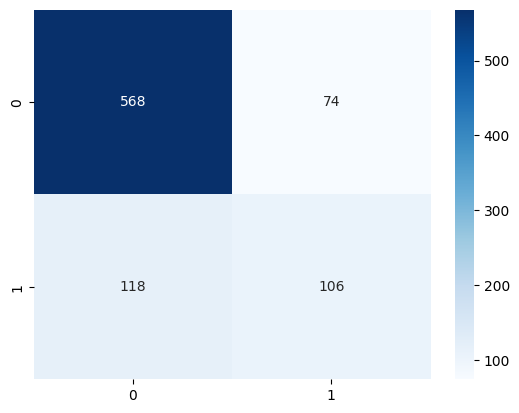

In [ ]:
model = train(X_alkane_train, y_alkane_train, "Alkane")
evaluate(model, X_alkane_test, y_alkane_test, "Alkane")

benzene

In [ ]:
X_benzene_matrice, y_benzene_labels = transforme_to_matrix(X_benzene, y_benzene, "benzene")
X_benzene_train, X_benzene_test, y_benzene_train, y_benzene_test = train_test_split(
    X_benzene_matrice, y_benzene_labels, test_size=0.2, random_state=42)

========== Traitement de benzene ==========
Nombre de graphes : 12000
Extraction des features en cours...
  > 1000 graphes traités
  > 2000 graphes traités
  > 3000 graphes traités
  > 4000 graphes traités
  > 5000 graphes traités
  > 6000 graphes traités
  > 7000 graphes traités
  > 8000 graphes traités
  > 9000 graphes traités
  > 10000 graphes traités
  > 11000 graphes traités
  > 12000 graphes traités
Matrice générée : (12000, 77) (Graphes x Features)


In [ ]:
print(f"classe 0: {df_benzene[df_benzene['label']==0].value_counts().sum()}, classe 1: {df_benzene[df_benzene['label']==1].value_counts().sum()}")

classe 0: 5999, classe 1: 6001


========== Entraînement sur benzene ==========
Entraînement du KNN...
========== Évaluation sur benzene ==========
Métriques de performance :
Accuracy: 0.9313
Rappel: 0.4774
Taux de faux positifs: 0.2970
Precision: 0.9561
F1 Score: 0.6368
AUC: 0.9308
Matrice de confusion:


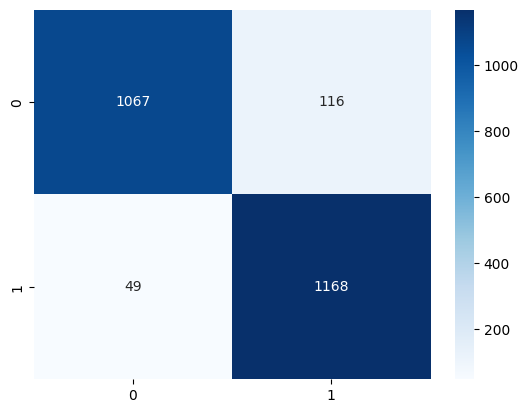

In [ ]:
model = train(X_benzene_train, y_benzene_train, "benzene")
evaluate(model, X_benzene_test, y_benzene_test, "benzene")